# Injection and recovery

Add point sources of known flux to a real 50 arcsec field and measure
them with the MER-prior path of the pipeline. Injection and recovery both
use the nearest GRID-PSF sample, so the test checks the fitting code, not
the PSF model itself.

We look at the recovered flux scale, the pull `(recovered - true) /
reported error`, and the fraction recovered with a valid fit and S/N > 5.
The injected signal is noiseless: source Poisson noise is not simulated.

In [1]:
# Locate the package when running from either notebook directory.
import os, sys
from pathlib import Path
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "src/euclid_phot").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from the repository.")
if "euclid_phot" in sys.modules:
    loaded_from = Path(sys.modules["euclid_phot"].__file__).resolve()
    if loaded_from != (PROJECT_ROOT / "src/euclid_phot/__init__.py").resolve():
        raise RuntimeError("Restart the kernel to load this repository's package.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.environ.setdefault("EUCLID_PHOT_DATA_DIR", str(PROJECT_ROOT / "examples/native_data"))

import numpy as np
from astropy.table import vstack
import matplotlib.pyplot as plt

from euclid_phot.injection import run_injection_recovery, summarize_recovery

TARGET_RA, TARGET_DEC = 269.48, 67.30
CUTOUT_SIZE_ARCSEC = 50.0
DATA_DIR = Path(os.environ.get("EUCLID_PHOT_DATA_DIR", "../examples/native_data"))

## 1. Bright sources: the flux scale

Thirty VIS point sources at 10 to 100 microJansky.

In [2]:
cat_b, truth_b = run_injection_recovery(
    data_dir=DATA_DIR, target_ra=TARGET_RA, target_dec=TARGET_DEC,
    cutout_size_arcsec=CUTOUT_SIZE_ARCSEC,
    bands=("VIS",), n_inject=30, flux_range_ujy=(10.0, 100.0), rng=1,
    injection_psf_product="grid", psf_product="grid")
s_b = summarize_recovery(cat_b, truth_b, band="VIS")
print(f"recovered {s_b['n_recovered']}/{s_b['n_injected']} injections")
print(f"flux bias:        median(out/true) = {s_b['ratio_median']:.4f}")
print(f"recovery scatter: mad_std(out/true) = {s_b['ratio_mad']:.4f}")


recovered 30/30 injections
flux bias:        median(out/true) = 1.0001
recovery scatter: mad_std(out/true) = 0.0002


## 2. Faint sources: fluxes, uncertainties, and completeness

Five seeds of 40 sources each, at S/N of about 5 to 20 in VIS, Y, J, and
H. Each seed starts from the original image, and the 200 injections are
combined. A pull width (scaled MAD) near unity means the reported errors match the
recovered scatter.

In [3]:
FAINT = {"VIS": (0.04, 0.12), "Y": (0.4, 1.2),
         "J": (0.4, 1.2), "H": (0.45, 1.3)}
catalogs, truths = [], []
for seed in range(5):
    cat, truth = run_injection_recovery(
        data_dir=DATA_DIR, target_ra=TARGET_RA, target_dec=TARGET_DEC,
        cutout_size_arcsec=CUTOUT_SIZE_ARCSEC, bands=tuple(FAINT),
        n_inject=40, flux_range_ujy=FAINT, rng=seed,
        injection_psf_product="grid", psf_product="grid")
    # Injected rows have negative object_id; offset them so the seeds do not collide.
    cat = cat[np.isin(cat['object_id'], truth['object_id'])].copy()
    cat['object_id'] -= seed * 40
    truth['object_id'] -= seed * 40
    catalogs.append(cat)
    truths.append(truth)

cat_f = vstack(catalogs, metadata_conflicts='silent')
truth_f = vstack(truths, metadata_conflicts='silent')
summaries = {band: summarize_recovery(cat_f, truth_f, band=band) for band in FAINT}
print(f"{'band':>5} {'fitted/total':>13} {'ratio':>7} {'pull':>7} {'S/N>5 fraction':>15}")
for band, s in summaries.items():
    print(f"{band:>5} {s['n_recovered']:>6}/{s['n_injected']:<6} "
          f"{s['ratio_median']:7.3f} {s['pull_std']:7.3f} {s['completeness']:15.3f}")

 band  fitted/total   ratio    pull  S/N>5 fraction
  VIS    200/200      1.000   0.766           0.980
    Y    200/200      1.010   0.828           0.995
    J    200/200      0.995   0.915           0.995
    H    200/200      1.003   1.130           0.995


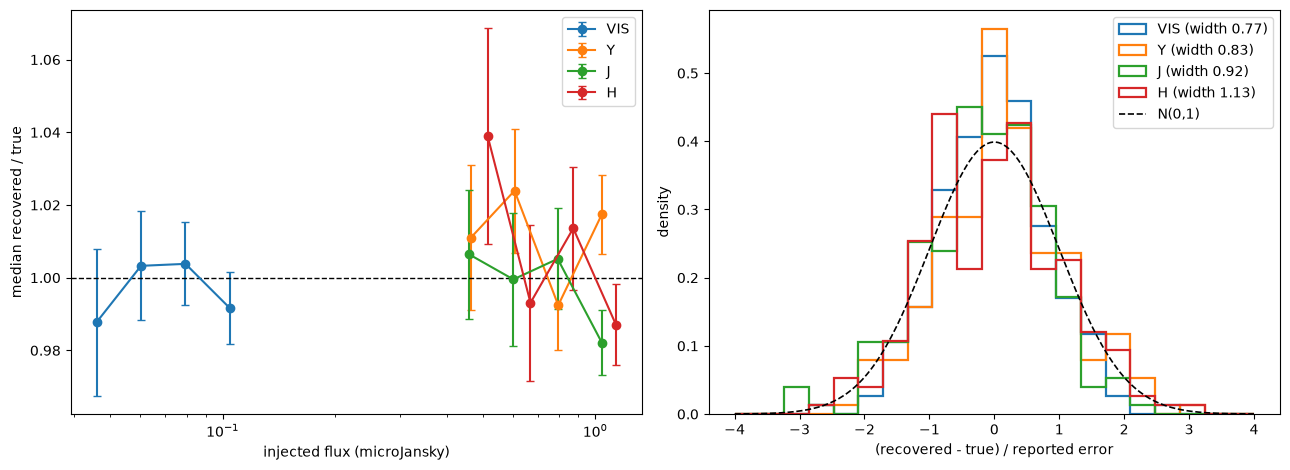

In [4]:
fig, (ax_bias, ax_pull) = plt.subplots(1, 2, figsize=(13, 4.8))

for band in FAINT:
    b = summaries[band]['bins']
    centre = np.sqrt(b['flux_lo_ujy'] * b['flux_hi_ujy'])
    ax_bias.errorbar(centre, b['ratio_median'], yerr=np.sqrt(np.pi / 2) * b['ratio_mad'] / np.sqrt(b['n']),
                     fmt='o-', capsize=3, label=band)
ax_bias.axhline(1.0, color='k', ls='--', lw=1)
ax_bias.set_xscale('log')
ax_bias.set_xlabel('injected flux (microJansky)')
ax_bias.set_ylabel('median recovered / true')
ax_bias.legend()

x = np.linspace(-4, 4, 200)
for band in FAINT:
    ax_pull.hist(summaries[band]['pull'], bins=np.linspace(-4, 4, 22),
                 density=True, histtype='step', lw=1.6,
                 label=f"{band} (width {summaries[band]['pull_std']:.2f})")
ax_pull.plot(x, np.exp(-x**2 / 2) / np.sqrt(2 * np.pi), 'k--', lw=1.2, label='N(0,1)')
ax_pull.set_xlabel('(recovered - true) / reported error')
ax_pull.set_ylabel('density')
ax_pull.legend()
plt.tight_layout()
plt.show()

The left panel is the flux bias per bin of injected flux, with the error
on the median as the error bar; the right panel compares the pull
distributions with a unit Gaussian.